In [22]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [23]:

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
dataset_path = "part_2_cnn_computer_vision/images"

## Task 1 : Problem Identification


In [25]:
classes = os.listdir(dataset_path)

print(classes)

['dent', 'normal', 'scratch', 'stain']


## TASK 2 : Dataset Exploration

#### Number of classes & Number of images per class



In [26]:
for cls in classes:
    
    class_path = os.path.join(dataset_path, cls)
    
    image_count = len(os.listdir(class_path))
    
    print(f"{cls}: {image_count} images")

dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


#### Sample images from each class


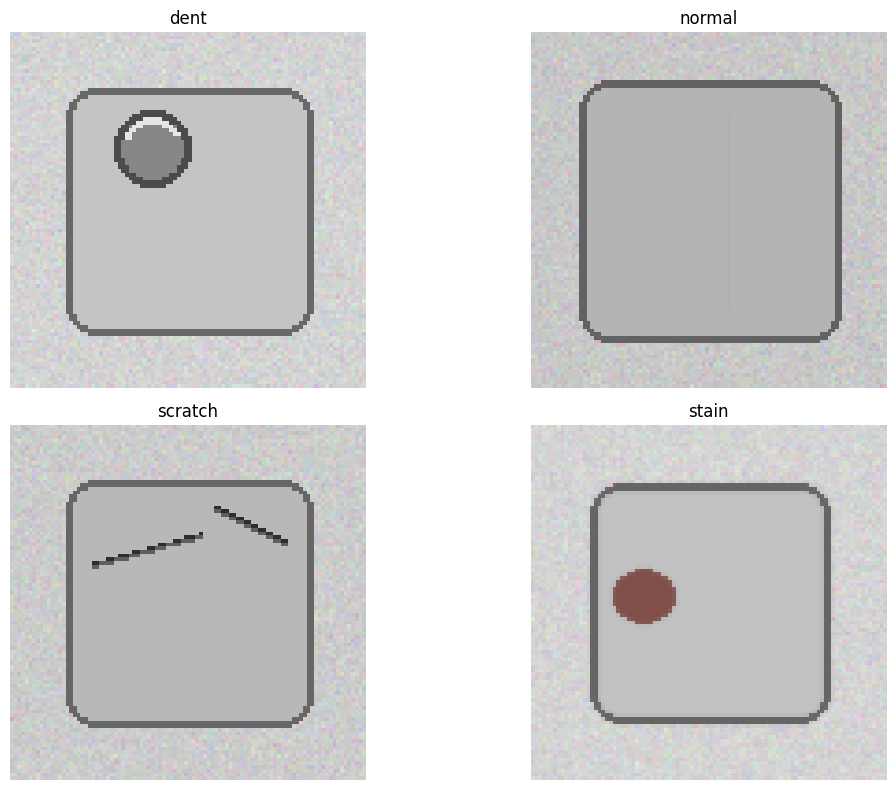

In [27]:
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    
    class_path = os.path.join(dataset_path, cls)
    
    image_name = os.listdir(class_path)[0]
    
    image_path = os.path.join(class_path, image_name)
    
    image = cv2.imread(image_path)
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 2, i + 1)
    
    plt.imshow(image)
    
    plt.title(cls)
    
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Image dimensions


In [28]:
sample_image_path = os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0])

image = cv2.imread(sample_image_path)

print("Image Shape:", image.shape)

Image Shape: (96, 96, 3)


## TASK 3 : Image Preprocessing 

#### Resizing images to a fixed size


In [29]:
X = []
y = []

IMG_SIZE = 96

for cls in classes:
    
    class_path = os.path.join(dataset_path, cls)
    
    for image_name in os.listdir(class_path):
        
        image_path = os.path.join(class_path, image_name)
        
        image = cv2.imread(image_path)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        
        X.append(image)
        
        y.append(cls)

print("Total Images Processed:", len(X))

Total Images Processed: 480


#### Normalizing pixel values


In [30]:
x = np.array(X)

x = x / 255.0

print("Minimum Pixel Value:", x.min())
print("Maximum Pixel Value:", x.max())

Minimum Pixel Value: 0.17647058823529413
Maximum Pixel Value: 1.0


#### Encoding

In [31]:
label_map = {
    'dent': 0,
    'normal': 1,
    'scratch': 2,
    'stain': 3
}

y = np.array([label_map[label] for label in y])

print(y[:10])
print(type(y[0]))

[0 0 0 0 0 0 0 0 0 0]
<class 'numpy.int64'>


#### Splitting into training and testing sets


In [32]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", len(x_train))
print("Testing Images:", len(x_test))

Training Images: 384
Testing Images: 96


#### Applying augmentation, if needed


In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True
)

print("Data augmentation configured successfully.")

Data augmentation configured successfully.


## TASK 4 : CNN Model Creation

In [34]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(96, 96, 3)),
    
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(4, activation='softmax')

])

model.summary()

c:\Users\Home\Desktop\Business Analytics with Gen AI\Neural Networks & Deep Learning\Assignment Module 5\Q2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

## TASK 5 : Model Training and Evaluation

In [35]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


#### Training the CNN Model

In [36]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 604ms/step - accuracy: 0.2150 - loss: 1.6138 - val_accuracy: 0.2597 - val_loss: 1.3853
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.3844 - loss: 1.3485 - val_accuracy: 0.4675 - val_loss: 1.3057
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step - accuracy: 0.4625 - loss: 1.1866 - val_accuracy: 0.4545 - val_loss: 1.1606
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 291ms/step - accuracy: 0.5603 - loss: 0.9581 - val_accuracy: 0.5844 - val_loss: 1.0185
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 297ms/step - accuracy: 0.7394 - loss: 0.7482 - val_accuracy: 0.6494 - val_loss: 0.9305
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - accuracy: 0.8371 - loss: 0.5471 - val_accuracy: 0.7403 - val_loss: 0.7024
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - accuracy: 0.8958 - loss: 0.3732 - val_accuracy: 0.7403 - val_loss: 0.6294
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 469ms/step - accuracy: 0.9218 - loss: 0.2993 - val_accuracy: 0

#### Training accuracy/loss & Validation accuracy/loss


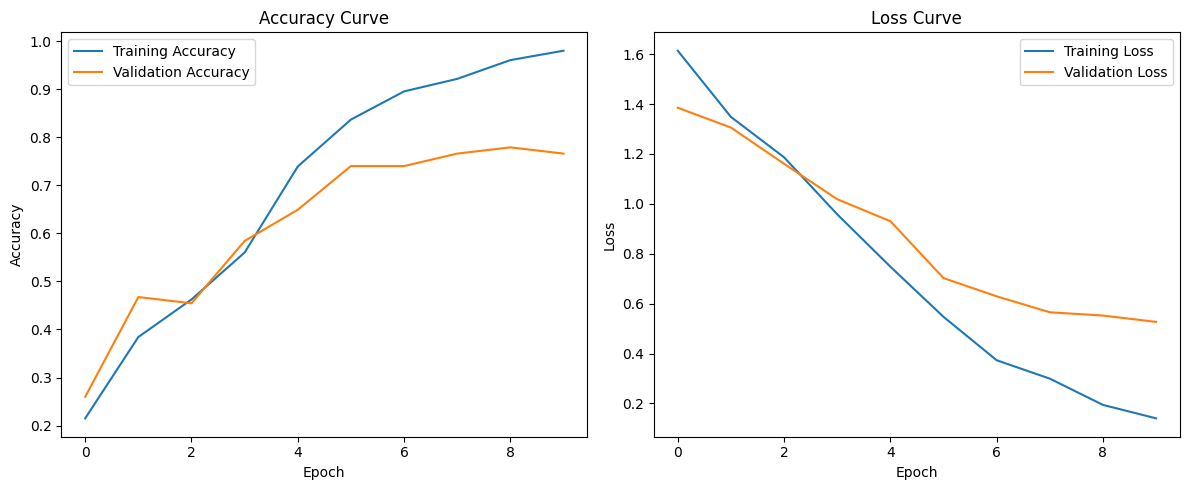

In [37]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()


# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

#### Testing the CNN Model

In [38]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8333 - loss: 0.4611
Test Accuracy: 0.8333333134651184
Test Loss: 0.46110275387763977


#### Confusion Matrix

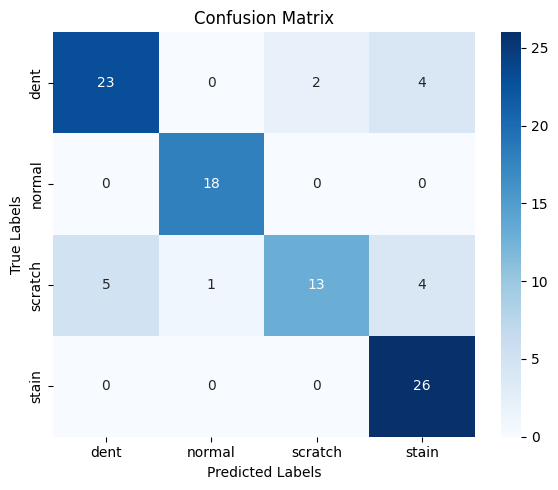

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig("results/confusion_matrix.png")

plt.show()

#### Sample Predictions on Test Images

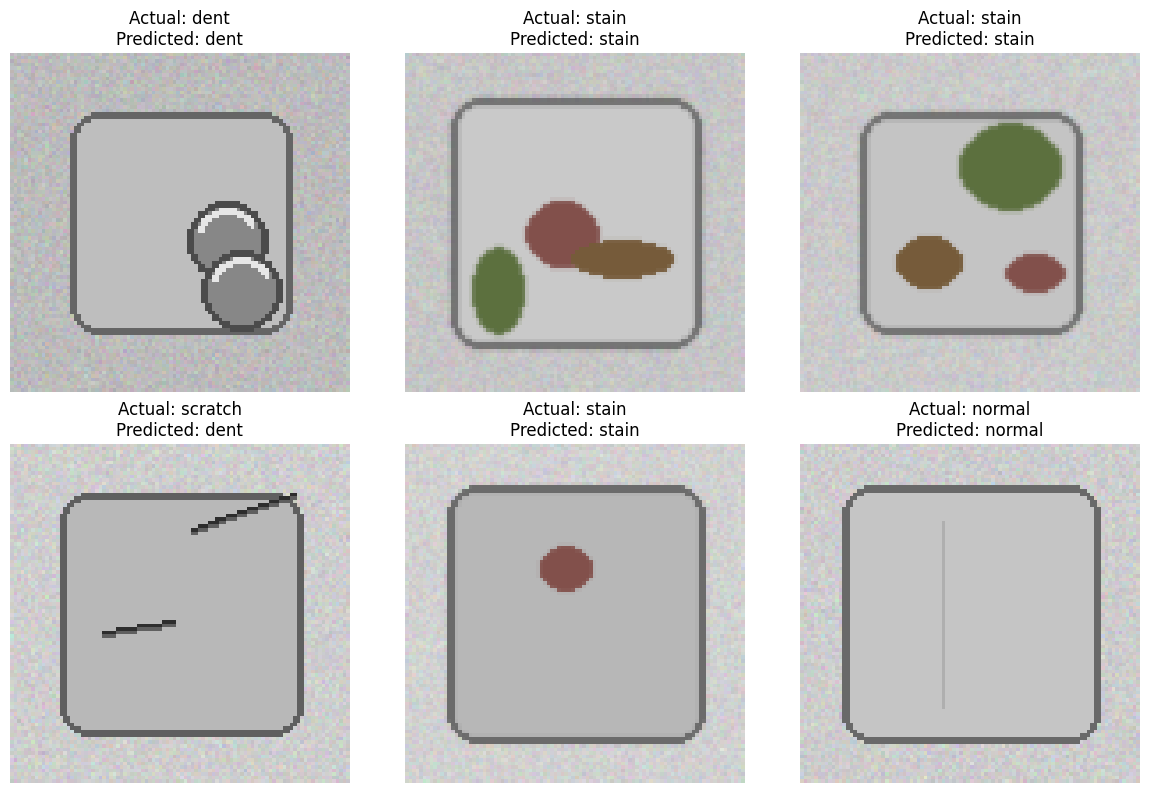

In [40]:
class_names = ['dent', 'normal', 'scratch', 'stain']

plt.figure(figsize=(12,8))

for i in range(6):
    
    plt.subplot(2, 3, i + 1)
    
    plt.imshow(x_test[i])
    
    actual_label = class_names[y_test[i]]
    
    predicted_label = class_names[y_pred_classes[i]]
    
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    
    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()